# 04 — Enriquecimento geográfico e contextual dos dados do SINAN

## Objetivo

Este notebook realiza o enriquecimento geográfico e contextual dos dados do
SINAN previamente pré-processados e validados.

As etapas anteriores já produziram variáveis analíticas e decodificadas,
incluindo semana epidemiológica, Unidade Federativa, sorotipo,
hospitalização e evolução dos casos.

Nesta etapa são acrescentadas informações externas de referência,
principalmente provenientes do IBGE, permitindo associar os registros do
SINAN a:

- código municipal padronizado;
- código IBGE de 7 dígitos;
- nome do município;
- Unidade Federativa;
- região geográfica;
- população municipal.

Essas informações serão posteriormente utilizadas para cálculo de
indicadores epidemiológicos, como incidência, no notebook de análises
agregadas.

Notebooks:

03 → "Os dados são adequados?"

04 → "Como tornar esses dados semanticamente mais ricos?"

05 → "O que esses dados mostram epidemiologicamente?"

06 → "Como transformar os resultados em documentos para o RAG?"


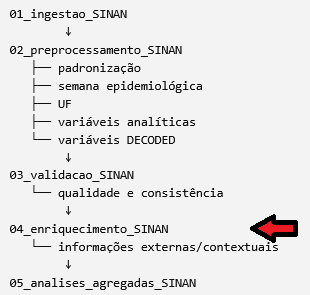

Então qual deve ser a verdadeira função do notebook 04?

Ele deve realizar principalmente enriquecimento externo, especialmente geográfico e populacional.

## 1 - Montagem do drive

In [1]:
from google.colab import drive
import os

drive.mount("/content/drive")

Mounted at /content/drive


##2 - Imports

In [2]:
import pandas as pd
import numpy as np

from pathlib import Path
from datetime import datetime

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

## 3 - Configuração geral

In [3]:
# ============================================================
# CONFIGURAÇÃO
# ============================================================

ANO = 2026

PASTA_BASE = Path(
    "/content/drive/MyDrive/Doutorado/arbovirus_rag"
)

PASTA_PROCESSED = (
    PASTA_BASE
    / "data_processed"
    / "SINAN"
    / str(ANO)
)

PASTA_PROCESSED.mkdir(
    parents=True,
    exist_ok=True
)

# ============================================================
# REFERÊNCIA MUNICIPAL DO IBGE
# ============================================================

PASTA_IBGE = (
    PASTA_BASE
    / "data_reference"
    / "IBGE"
)

PASTA_IBGE.mkdir(
    parents=True,
    exist_ok=True
)

ARQUIVO_IBGE = (
    PASTA_IBGE
    / "dim_municipios_ibge_validada.parquet"
)

print(
    ARQUIVO_IBGE
)


print("Ano:", ANO)
print("Pasta:", PASTA_PROCESSED)

/content/drive/MyDrive/Doutorado/arbovirus_rag/data_reference/IBGE/dim_municipios_ibge_validada.parquet
Ano: 2026
Pasta: /content/drive/MyDrive/Doutorado/arbovirus_rag/data_processed/SINAN/2026


## 4. Carregar o dataframe produzido pelo notebook 02

Aqui mantenho o mesmo arquivo que foi usado no notebook 03.

Por exemplo:

In [4]:
# ============================================================
# ARQUIVO DE ENTRADA
# ============================================================

ARQUIVO_ENTRADA = (
    PASTA_PROCESSED
    / f"sinan_dengue_{ANO}_preprocessado.parquet"
)

print("Arquivo de entrada:")
print(ARQUIVO_ENTRADA)

Arquivo de entrada:
/content/drive/MyDrive/Doutorado/arbovirus_rag/data_processed/SINAN/2026/sinan_dengue_2026_preprocessado.parquet


In [5]:
# ============================================================
# CARREGAMENTO
# ============================================================

df = pd.read_parquet(
    ARQUIVO_ENTRADA
)

print(
    f"Registros carregados: "
    f"{len(df):,}"
)

print(
    f"Variáveis: "
    f"{df.shape[1]}"
)

Registros carregados: 444,266
Variáveis: 152


In [6]:
display(
    df.head()
)

,TP_NOT,ID_AGRAVO,DT_NOTIFIC,SEM_NOT,NU_ANO,SG_UF_NOT,ID_MUNICIP,ID_REGIONA,ID_UNIDADE,DT_SIN_PRI,SEM_PRI,ANO_NASC,NU_IDADE_N,CS_SEXO,CS_GESTANT,CS_RACA,CS_ESCOL_N,SG_UF,ID_MN_RESI,ID_RG_RESI,ID_PAIS,DT_INVEST,ID_OCUPA_N,FEBRE,MIALGIA,CEFALEIA,EXANTEMA,VOMITO,NAUSEA,DOR_COSTAS,CONJUNTVIT,ARTRITE,ARTRALGIA,PETEQUIA_N,LEUCOPENIA,LACO,DOR_RETRO,DIABETES,HEMATOLOG,HEPATOPAT,RENAL,HIPERTENSA,ACIDO_PEPT,AUTO_IMUNE,DT_CHIK_S1,DT_CHIK_S2,DT_PRNT,RES_CHIKS1,RES_CHIKS2,RESUL_PRNT,DT_SORO,RESUL_SORO,DT_NS1,RESUL_NS1,DT_VIRAL,RESUL_VI_N,DT_PCR,RESUL_PCR_,SOROTIPO,HISTOPA_N,IMUNOH_N,HOSPITALIZ,DT_INTERNA,UF,MUNICIPIO,TPAUTOCTO,COUFINF,COPAISINF,COMUNINF,CLASSI_FIN,CRITERIO,DOENCA_TRA,CLINC_CHIK,EVOLUCAO,DT_OBITO,DT_ENCERRA,ALRM_HIPOT,ALRM_PLAQ,ALRM_VOM,ALRM_SANG,ALRM_HEMAT,ALRM_ABDOM,ALRM_LETAR,ALRM_HEPAT,ALRM_LIQ,DT_ALRM,GRAV_PULSO,GRAV_CONV,GRAV_ENCH,GRAV_INSUF,GRAV_TAQUI,GRAV_EXTRE,GRAV_HIPOT,GRAV_HEMAT,GRAV_MELEN,GRAV_METRO,GRAV_SANG,GRAV_AST,GRAV_MIOC,GRAV_CONSC,GRAV_ORGAO,DT_GRAV,MANI_HEMOR,EPISTAXE,GENGIVO,METRO,PETEQUIAS,HEMATURA,SANGRAM,LACO_N,PLASMATICO,EVIDENCIA,PLAQ_MENOR,CON_FHD,COMPLICA,TP_SISTEMA,NDUPLIC_N,DT_DIGITA,CS_FLXRET,FLXRECEBI,MIGRADO_W,SEMANA_EPIDEMIOLOGICA,ANO_SEM_NOT,UF_NAME,SOROTIPO_ANALITICO,HOSPITALIZ_ANALITICO,EVOLUCAO_ANALITICO,SOROTIPO_DECODED,HOSPITALIZ_DECODED,EVOLUCAO_DECODED,FEBRE_DECODED,MIALGIA_DECODED,CEFALEIA_DECODED,EXANTEMA_DECODED,VOMITO_DECODED,NAUSEA_DECODED,DOR_COSTAS_DECODED,CONJUNTVIT_DECODED,ARTRITE_DECODED,ARTRALGIA_DECODED,PETEQUIA_N_DECODED,LEUCOPENIA_DECODED,LACO_DECODED,DOR_RETRO_DECODED,DIABETES_DECODED,HEMATOLOG_DECODED,HEPATOPAT_DECODED,RENAL_DECODED,HIPERTENSA_DECODED,ACIDO_PEPT_DECODED,AUTO_IMUNE_DECODED,TPAUTOCTO_DECODED
0,2,A90,2026-05-19,202620,2026,32,320400,32001,2448653,2026-05-14,202619,1978,4048,F,5,1,8,32,320400,32001,1,2026-05-18,251605,1,1,2,1,2,1,1,2,2,1,1,1,2,1,2,2,2,2,2,2,2,None,None,None,0,0,0,None,4,2026-05-18,1,None,4,None,4,0,0,0,2,None,0,0,1,0,0,0,10,1,0,1,1,None,2026-05-25,0,0,0,0,0,0,0,0,0,None,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,None,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,2025-11-08,0,0,0,20,2026,Espírito Santo,<NA>,2,1,None,Não,Cura,Sim,Sim,Não,Sim,Não,Sim,Sim,Não,Não,Sim,Sim,Sim,Não,Sim,Não,Não,Não,Não,Não,Não,Não,Sim
1,2,A90,2026-01-05,202601,2026,32,320500,32002,2499495,2026-01-04,202601,1984,4041,F,5,4,5,32,320500,32002,1,2026-01-05,0,1,1,1,2,2,2,1,2,2,2,2,2,2,2,2,2,2,2,1,2,2,None,None,None,0,0,0,None,4,2026-01-05,2,None,4,None,4,0,0,0,2,None,0,0,1,0,0,0,10,2,0,1,1,None,2026-01-20,0,0,0,0,0,0,0,0,0,None,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,None,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,2026-01-05,0,0,0,1,2026,Espírito Santo,<NA>,2,1,None,Não,Cura,Sim,Sim,Sim,Não,Não,Não,Sim,Não,Não,Não,Não,Não,Não,Não,Não,Não,Não,Não,Sim,Não,Não,Sim
2,2,A90,2026-01-05,202601,2026,32,320500,32002,2522772,2026-01-05,202601,1991,4034,F,5,2,6,32,320500,32002,1,2026-01-05,322215,1,2,1,2,1,2,2,2,2,2,1,2,2,2,2,2,2,2,2,2,2,None,None,None,0,0,0,None,0,1920-01-05,2,None,4,None,0,0,0,0,2,None,0,0,1,0,0,0,10,2,0,1,1,None,2026-01-20,0,0,0,0,0,0,0,0,0,None,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,None,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,2026-01-05,0,0,0,1,2026,Espírito Santo,<NA>,2,1,None,Não,Cura,Sim,Não,Sim,Não,Sim,Não,Não,Não,Não,Não,Sim,Não,Não,Não,Não,Não,Não,Não,Não,Não,Não,Sim
3,2,A90,2026-01-05,202601,2026,32,320500,32002,7838131,2026-01-04,202601,1998,4027,M,6,4,9,32,320500,32002,1,2026-01-05,10001,1,2,1,2,1,1,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,None,None,None,0,0,0,None,4,None,4,None,4,None,4,0,0,0,2,None,0,0,1,0,0,0,10,2,0,1,9,None,2026-01-05,0,0,0,0,0,0,0,0,0,None,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,None,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,2026-01-05,0,0,0,1,2026,Espírito Santo,<NA>,2,9,None,Não,Ignorado,Sim,Não,Sim,Não,Sim,Sim,Não,Não,Não,Não,Não,Não,Não,Não,Não,Não,Não,Não,Não,Não,Não,Sim
4,2,A90,2026-01-05,202601,2026,32,320530,32002,11789,2026-01-05,202601,1997,4028,M,6,4,9,32,320530,32002,1,2026-01-05,411010,1,1,1,2,2,1,1,2,2,1,2,2,2,1,2,2,2,2,2,2,2,None,None,None,0,0,0,None,4,None,4,None,4,None,4,0,0,0,2,None,0,0,1,0,0,0,10,2,0,0,1,No

In [7]:
for i, coluna in enumerate(df.columns, start=1):
    print(f"{i:3} - {coluna}")

  1 - TP_NOT
  2 - ID_AGRAVO
  3 - DT_NOTIFIC
  4 - SEM_NOT
  5 - NU_ANO
  6 - SG_UF_NOT
  7 - ID_MUNICIP
  8 - ID_REGIONA
  9 - ID_UNIDADE
 10 - DT_SIN_PRI
 11 - SEM_PRI
 12 - ANO_NASC
 13 - NU_IDADE_N
 14 - CS_SEXO
 15 - CS_GESTANT
 16 - CS_RACA
 17 - CS_ESCOL_N
 18 - SG_UF
 19 - ID_MN_RESI
 20 - ID_RG_RESI
 21 - ID_PAIS
 22 - DT_INVEST
 23 - ID_OCUPA_N
 24 - FEBRE
 25 - MIALGIA
 26 - CEFALEIA
 27 - EXANTEMA
 28 - VOMITO
 29 - NAUSEA
 30 - DOR_COSTAS
 31 - CONJUNTVIT
 32 - ARTRITE
 33 - ARTRALGIA
 34 - PETEQUIA_N
 35 - LEUCOPENIA
 36 - LACO
 37 - DOR_RETRO
 38 - DIABETES
 39 - HEMATOLOG
 40 - HEPATOPAT
 41 - RENAL
 42 - HIPERTENSA
 43 - ACIDO_PEPT
 44 - AUTO_IMUNE
 45 - DT_CHIK_S1
 46 - DT_CHIK_S2
 47 - DT_PRNT
 48 - RES_CHIKS1
 49 - RES_CHIKS2
 50 - RESUL_PRNT
 51 - DT_SORO
 52 - RESUL_SORO
 53 - DT_NS1
 54 - RESUL_NS1
 55 - DT_VIRAL
 56 - RESUL_VI_N
 57 - DT_PCR
 58 - RESUL_PCR_
 59 - SOROTIPO
 60 - HISTOPA_N
 61 - IMUNOH_N
 62 - HOSPITALIZ
 63 - DT_INTERNA
 64 - UF
 65 - MUNICIPIO

## 5. Inventário das variáveis já enriquecidas

Esse trecho é importante porque documenta que não estamos recriando variáveis do notebook 02.

In [8]:
# ============================================================
# INVENTÁRIO DAS VARIÁVEIS NECESSÁRIAS AO ENRIQUECIMENTO
# ============================================================

GRUPOS_VARIAVEIS = {

    "Temporal": [
        "NU_ANO",
        "SEM_NOT",
        "SEMANA_EPIDEMIOLOGICA"
    ],

    "Epidemiológicas": [
        "SOROTIPO",
        "HOSPITALIZ",
        "EVOLUCAO",
        "SOROTIPO_ANALITICO",
        "HOSPITALIZ_ANALITICO",
        "EVOLUCAO_ANALITICO",
        "SOROTIPO_DECODED",
        "HOSPITALIZ_DECODED",
        "EVOLUCAO_DECODED"
    ],

    "Sinais clínicos": [
        "FEBRE_DECODED",
        "MIALGIA_DECODED",
        "CEFALEIA_DECODED",
        "EXANTEMA_DECODED",
        "VOMITO_DECODED",
        "NAUSEA_DECODED",
        "DOR_COSTAS_DECODED",
        "CONJUNTVIT_DECODED",
        "ARTRITE_DECODED",
        "ARTRALGIA_DECODED",
        "PETEQUIA_N_DECODED",
        "LEUCOPENIA_DECODED",
        "LACO_DECODED",
        "DOR_RETRO_DECODED"
    ],

    "Doenças pré-existentes": [
        "DIABETES_DECODED",
        "HEMATOLOG_DECODED",
        "HEPATOPAT_DECODED",
        "RENAL_DECODED",
        "HIPERTENSA_DECODED",
        "ACIDO_PEPT_DECODED",
        "AUTO_IMUNE_DECODED"
    ],

    "Autoctonia": [
        "TPAUTOCTO",
        "TPAUTOCTO_DECODED"
    ],

    "Notificação": [
        "SG_UF_NOT",
        "ID_MUNICIP"
    ],

    "Residência": [
        "SG_UF",
        "ID_MN_RESI"
    ],

    "Fonte provável de infecção": [
        "COUFINF",
        "COPAISINF",
        "COMUNINF"
    ]
}

# ============================================================
# CONSTRUÇÃO DO INVENTÁRIO
# ============================================================

inventario = []

for grupo, variaveis in GRUPOS_VARIAVEIS.items():

    for coluna in variaveis:

        inventario.append({
            "GRUPO": grupo,
            "VARIAVEL": coluna,
            "EXISTE_NO_DATAFRAME": coluna in df.columns
        })

df_inventario = pd.DataFrame(inventario)

display(df_inventario)

,GRUPO,VARIAVEL,EXISTE_NO_DATAFRAME
0,Temporal,NU_ANO,True
1,Temporal,SEM_NOT,True
2,Temporal,SEMANA_EPIDEMIOLOGICA,True
3,Epidemiológicas,SOROTIPO,True
4,Epidemiológicas,HOSPITALIZ,True
5,Epidemiológicas,EVOLUCAO,True
6,Epidemiológicas,SOROTIPO_ANALITICO,True
7,Epidemiológicas,HOSPITALIZ_ANALITICO,True
8,Epidemiológicas,EVOLUCAO_ANALITICO,True
9,Epidemiológicas,SOROTIPO_DECODED,True


In [9]:
# ============================================================
# INSPEÇÃO DAS VARIÁVEIS CATEGÓRICAS DECODIFICADAS
# ============================================================

VARIAVEIS_CATEGORICAS_DECODIFICADAS = [

    # Epidemiológicas
    "SOROTIPO_DECODED",
    "HOSPITALIZ_DECODED",
    "EVOLUCAO_DECODED",

    # Sinais clínicos
    "FEBRE_DECODED",
    "MIALGIA_DECODED",
    "CEFALEIA_DECODED",
    "EXANTEMA_DECODED",
    "VOMITO_DECODED",
    "NAUSEA_DECODED",
    "DOR_COSTAS_DECODED",
    "CONJUNTVIT_DECODED",
    "ARTRITE_DECODED",
    "ARTRALGIA_DECODED",
    "PETEQUIA_N_DECODED",
    "LEUCOPENIA_DECODED",
    "LACO_DECODED",
    "DOR_RETRO_DECODED",

    # Doenças pré-existentes
    "DIABETES_DECODED",
    "HEMATOLOG_DECODED",
    "HEPATOPAT_DECODED",
    "RENAL_DECODED",
    "HIPERTENSA_DECODED",
    "ACIDO_PEPT_DECODED",
    "AUTO_IMUNE_DECODED",

    # Autoctonia
    "TPAUTOCTO_DECODED"
]

for coluna in VARIAVEIS_CATEGORICAS_DECODIFICADAS:

    if coluna not in df.columns:
        print(f"⚠ {coluna}: coluna não encontrada")
        continue

    print("=" * 60)
    print(coluna)
    print("=" * 60)

    contagem = (
        df[coluna]
        .value_counts(dropna=False)
        .rename_axis("VALOR")
        .reset_index(name="TOTAL")
    )

    contagem["PERCENTUAL"] = (
        contagem["TOTAL"] / len(df) * 100
    ).round(2)

    display(contagem)

SOROTIPO_DECODED


,VALOR,TOTAL,PERCENTUAL
0,None,414749,93.36
1,DENV-2,18763,4.22
2,DENV-3,9017,2.03
3,DENV-1,1631,0.37
4,DENV-4,106,0.02


HOSPITALIZ_DECODED


,VALOR,TOTAL,PERCENTUAL
0,Não,298342,67.15
1,None,109080,24.55
2,Sim,27589,6.21
3,Ignorado,9255,2.08


EVOLUCAO_DECODED


...

,VALOR,TOTAL,PERCENTUAL
0,Não,426529,96.01
1,None,15598,3.51
2,Sim,2139,0.48


AUTO_IMUNE_DECODED


,VALOR,TOTAL,PERCENTUAL
0,Não,425907,95.87
1,None,15598,3.51
2,Sim,2761,0.62


TPAUTOCTO_DECODED


,VALOR,TOTAL,PERCENTUAL
0,Sim,257191,57.89
1,None,163050,36.70
2,Indeterminado,18002,4.05
3,Não,6023,1.36


In [10]:
# ============================================================
# INSPEÇÃO DAS VARIÁVEIS DE FONTE PROVÁVEL DE INFECÇÃO
# ============================================================

VARIAVEIS_FONTE_INFECCAO = [
    "COUFINF",
    "COPAISINF",
    "COMUNINF"
]

resumo_fonte_infeccao = []

for coluna in VARIAVEIS_FONTE_INFECCAO:

    if coluna not in df.columns:
        continue

    total = len(df)
    preenchidos = df[coluna].notna().sum()
    ausentes = df[coluna].isna().sum()
    distintos = df[coluna].nunique(dropna=True)

    resumo_fonte_infeccao.append({
        "VARIAVEL": coluna,
        "TOTAL_REGISTROS": total,
        "PREENCHIDOS": preenchidos,
        "AUSENTES": ausentes,
        "PERCENTUAL_PREENCHIMENTO": round(
            preenchidos / total * 100, 2
        ),
        "VALORES_DISTINTOS": distintos
    })

df_resumo_fonte_infeccao = pd.DataFrame(
    resumo_fonte_infeccao
)

display(df_resumo_fonte_infeccao)

,VARIAVEL,TOTAL_REGISTROS,PREENCHIDOS,AUSENTES,PERCENTUAL_PREENCHIMENTO,VALORES_DISTINTOS
0,COUFINF,444266,444266,0,100.0,29
1,COPAISINF,444266,444266,0,100.0,14
2,COMUNINF,444266,444266,0,100.0,3613


In [11]:
#códigos existentes
display(
    df["COUFINF"]
    .value_counts(dropna=False)
    .rename_axis("COUFINF")
    .reset_index(name="TOTAL")
)

,COUFINF,TOTAL
0,,183305
1,52,82931
2,35,48346
3,31,28601
4,0,19240
5,23,9499
6,17,8967
7,51,8966
8,22,8155
9,29,7987


In [12]:
display(
    df["COPAISINF"]
    .value_counts(dropna=False)
    .rename_axis("COPAISINF")
    .reset_index(name="TOTAL")
)

,COPAISINF,TOTAL
0,1,241679
1,,183289
2,0,19276
3,199,8
4,126,3
5,138,2
6,156,2
7,193,1
8,68,1
9,32,1


In [13]:
display(
    df["COMUNINF"]
    .value_counts(dropna=False)
    .head(20)
    .rename_axis("COMUNINF")
    .reset_index(name="TOTAL")
)

,COMUNINF,TOTAL
0,,184296
1,520870,28062
2,520140,19321
3,0,19240
4,355030,7452
5,521190,6389
6,521880,6089
7,354980,4637
8,170210,4437
9,355410,3988


O ponto mais importante para o notebook 04

Com a listagem das 152 colunas, agora temos uma divisão bem clara:

Já enriquecido/decodificado antes do notebook 04:

* SOROTIPO, HOSPITALIZ, EVOLUCAO → versões analíticas/decodificadas

* Sinais clínicos → versões *_DECODED

* Doenças pré-existentes → versões *_DECODED

* TPAUTOCTO → TPAUTOCTO_DECODED

Ainda precisa de enriquecimento geográfico no 04:

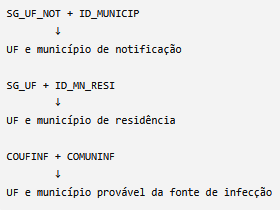

E o IBGE pode acrescentar nome, região, população, latitude, longitude, capital etc., dependendo do papel geográfico que você queira representar.

Faremos (diagnóstico de COUFINF, COPAISINF e COMUNINF) antes de escrevermos o merge com o IBGE. O resultado dela vai nos mostrar como esses códigos estão efetivamente armazenados no SINAN e evitar assumir incorretamente o formato dos códigos.

In [14]:
# ============================================================
# DIAGNÓSTICO DAS VARIÁVEIS DE FONTE PROVÁVEL DE INFECÇÃO
# ============================================================

VARIAVEIS_FONTE_INFECCAO = [
    "COUFINF",
    "COPAISINF",
    "COMUNINF"
]

resumo_fonte_infeccao = []

for coluna in VARIAVEIS_FONTE_INFECCAO:

    if coluna not in df.columns:
        print(f"⚠ {coluna}: coluna não encontrada")
        continue

    total = len(df)
    preenchidos = df[coluna].notna().sum()
    ausentes = df[coluna].isna().sum()
    distintos = df[coluna].nunique(dropna=True)

    resumo_fonte_infeccao.append({
        "VARIAVEL": coluna,
        "TIPO": str(df[coluna].dtype),
        "TOTAL_REGISTROS": total,
        "PREENCHIDOS": preenchidos,
        "AUSENTES": ausentes,
        "PERCENTUAL_PREENCHIMENTO": round(
            preenchidos / total * 100,
            2
        ),
        "VALORES_DISTINTOS": distintos
    })

df_resumo_fonte_infeccao = pd.DataFrame(
    resumo_fonte_infeccao
)

display(df_resumo_fonte_infeccao)

,VARIAVEL,TIPO,TOTAL_REGISTROS,PREENCHIDOS,AUSENTES,PERCENTUAL_PREENCHIMENTO,VALORES_DISTINTOS
0,COUFINF,object,444266,444266,0,100.0,29
1,COPAISINF,object,444266,444266,0,100.0,14
2,COMUNINF,object,444266,444266,0,100.0,3613


In [15]:
# ============================================================
# VALORES DAS VARIÁVEIS DE FONTE PROVÁVEL DE INFECÇÃO
# ============================================================

for coluna in VARIAVEIS_FONTE_INFECCAO:

    if coluna not in df.columns:
        continue

    print("=" * 60)
    print(coluna)
    print("=" * 60)

    display(
        df[coluna]
        .value_counts(dropna=False)
        .head(30)
        .rename_axis("VALOR")
        .reset_index(name="TOTAL")
    )

COUFINF


,VALOR,TOTAL
0,,183305
1,52,82931
2,35,48346
3,31,28601
4,0,19240
5,23,9499
6,17,8967
7,51,8966
8,22,8155
9,29,7987


COPAISINF


,VALOR,TOTAL
0,1,241679
1,,183289
2,0,19276
3,199,8
4,126,3
5,138,2
6,156,2
7,193,1
8,68,1
9,32,1


COMUNINF


,VALOR,TOTAL
0,,184296
1,520870,28062
2,520140,19321
3,0,19240
4,355030,7452
5,521190,6389
6,521880,6089
7,354980,4637
8,170210,4437
9,355410,3988


In [16]:
# ============================================================
# AMOSTRA DA FONTE PROVÁVEL DE INFECÇÃO
# ============================================================

display(
    df[
        [
            "TPAUTOCTO",
            "TPAUTOCTO_DECODED",
            "COUFINF",
            "COPAISINF",
            "COMUNINF"
        ]
    ]
    .dropna(
        subset=[
            "COUFINF",
            "COMUNINF"
        ],
        how="all"
    )
    .head(30)
)

,TPAUTOCTO,TPAUTOCTO_DECODED,COUFINF,COPAISINF,COMUNINF
0,1,Sim,0,0,0
1,1,Sim,0,0,0
2,1,Sim,0,0,0
3,1,Sim,0,0,0
4,1,Sim,0,0,0
5,1,Sim,0,0,0
6,1,Sim,0,0,0
7,1,Sim,0,0,0
8,3,Indeterminado,0,0,0
9,1,Sim,0,0,0


In [17]:
# ============================================================
# FORMATO DOS CÓDIGOS DE MUNICÍPIO PROVÁVEL DE INFECÇÃO
# ============================================================

comuninf_validos = (
    df["COMUNINF"]
    .dropna()
    .astype(str)
    .str.strip()
)

display(
    comuninf_validos
    .str.len()
    .value_counts()
    .sort_index()
    .rename_axis("QUANTIDADE_CARACTERES")
    .reset_index(name="TOTAL")
)

,QUANTIDADE_CARACTERES,TOTAL
0,0,184296
1,1,19240
2,6,240730


Substituir o diagnóstico anterior por uma versão que trate "0" e string vazia como não informados:

In [18]:
# ============================================================
# DIAGNÓSTICO CORRIGIDO DA FONTE PROVÁVEL DE INFECÇÃO
# ============================================================

VARIAVEIS_FONTE_INFECCAO = [
    "COUFINF",
    "COPAISINF",
    "COMUNINF"
]

resumo_fonte_infeccao = []

for coluna in VARIAVEIS_FONTE_INFECCAO:

    serie = (
        df[coluna]
        .astype("string")
        .str.strip()
    )

    # Considera ausentes:
    # - NaN / <NA>
    # - string vazia
    # - código 0
    mascara_informado = (
        serie.notna()
        & (serie != "")
        & (serie != "0")
    )

    total = len(df)
    informados = mascara_informado.sum()
    nao_informados = total - informados

    resumo_fonte_infeccao.append({
        "VARIAVEL": coluna,
        "TOTAL_REGISTROS": total,
        "INFORMADOS": informados,
        "NAO_INFORMADOS": nao_informados,
        "PERCENTUAL_INFORMADO": round(
            informados / total * 100,
            2
        ),
        "VALORES_DISTINTOS_INFORMADOS": (
            serie[mascara_informado].nunique()
        )
    })

df_resumo_fonte_infeccao = pd.DataFrame(
    resumo_fonte_infeccao
)

display(df_resumo_fonte_infeccao)

,VARIAVEL,TOTAL_REGISTROS,INFORMADOS,NAO_INFORMADOS,PERCENTUAL_INFORMADO,VALORES_DISTINTOS_INFORMADOS
0,COUFINF,444266,241721,202545,54.41,27
1,COPAISINF,444266,241701,202565,54.40,12
2,COMUNINF,444266,240730,203536,54.19,3611


TPAUTOCTO = "1"

        ↓ decodificação
TPAUTOCTO_DECODED = "Sim"

FEBRE = "1"

        ↓
FEBRE_DECODED = "Sim"


SOROTIPO = "1"

        ↓
SOROTIPO_DECODED = "DENV-1"


O que propomos para COUFINF_NORMALIZADO é apenas preparar o código para integração:

COUFINF = "0"

        ↓ normalização
COUFINF_NORMALIZADO = \<NA>

COUFINF = "35"

        ↓ normalização
COUFINF_NORMALIZADO = "35"

Ou seja, "35" ainda não foi decodificado.

A decodificação/enriquecimento aconteceria depois:

COUFINF_NORMALIZADO = "35"

        ↓ referência IBGE
UF_PROVAVEL_INFECCAO = "São Paulo"

O mesmo vale para município:

COMUNINF = "355030"

        ↓
COMUNINF_NORMALIZADO = "355030"

        ↓ referência IBGE
MUNICIPIO_PROVAVEL_INFECCAO = "São Paulo"

| Coluna                        | Significado                      |
| ----------------------------- | -------------------------------- |
| `COUFINF`                     | código original do SINAN         |
| `COUFINF_NORMALIZADO`         | código preparado para integração |
| `UF_PROVAVEL_INFECCAO`        | nome obtido pelo enriquecimento  |
| `COMUNINF`                    | código original do SINAN         |
| `COMUNINF_NORMALIZADO`        | código preparado para integração |
| `MUNICIPIO_PROVAVEL_INFECCAO` | nome obtido pelo enriquecimento  |


Antes do merge, vamos criar versões normalizadas
Não alterar as colunas originais do SINAN. Criar colunas auxiliares:

In [19]:
# ============================================================
# NORMALIZAÇÃO DOS CÓDIGOS DA FONTE PROVÁVEL DE INFECÇÃO
# ============================================================

df["COUFINF_NORMALIZADO"] = (
    df["COUFINF"]
    .astype("string")
    .str.strip()
    .replace({
        "": pd.NA,
        "0": pd.NA
    })
)

df["COMUNINF_NORMALIZADO"] = (
    df["COMUNINF"]
    .astype("string")
    .str.strip()
    .replace({
        "": pd.NA,
        "0": pd.NA
    })
)

In [20]:
print("COUFINF_NORMALIZADO")
display(
    df["COUFINF_NORMALIZADO"]
    .value_counts(dropna=False)
)

print("\nCOMUNINF_NORMALIZADO")
display(
    df["COMUNINF_NORMALIZADO"]
    .value_counts(dropna=False)
    .head(20)
)

COUFINF_NORMALIZADO


,count
COUFINF_NORMALIZADO,
<NA>,202545
52,82931
35,48346
31,28601
23,9499
17,8967
51,8966
22,8155
29,7987



COMUNINF_NORMALIZADO


,count
COMUNINF_NORMALIZADO,
<NA>,203536
520870,28062
520140,19321
355030,7452
521190,6389
521880,6089
354980,4637
170210,4437
355410,3988


## 6. Conferir as variáveis geográficas disponíveis

Pelo seu dataframe, temos pelo menos:
SG_UF_NOT

ID_MUNICIP

SG_UF

ID_MN_RESI

É importante distinguir município de notificação de município de residência.

Para análises de incidência populacional, em geral faz mais sentido trabalhar com o município de residência.

Então vamos conferir:

In [21]:
# ============================================================
# VARIÁVEIS GEOGRÁFICAS DO SINAN
# ============================================================

COLUNAS_GEOGRAFICAS = [
    "SG_UF_NOT",
    "ID_MUNICIP",
    "SG_UF",
    "ID_MN_RESI",
    "UF_NAME"
]

COLUNAS_EXISTENTES = [
    coluna
    for coluna in COLUNAS_GEOGRAFICAS
    if coluna in df.columns
]

display(
    df[
        COLUNAS_EXISTENTES
    ].head(20)
)

,SG_UF_NOT,ID_MUNICIP,SG_UF,ID_MN_RESI,UF_NAME
0,32,320400,32,320400,Espírito Santo
1,32,320500,32,320500,Espírito Santo
2,32,320500,32,320500,Espírito Santo
3,32,320500,32,320500,Espírito Santo
4,32,320530,32,320530,Espírito Santo
5,32,320530,32,320520,Espírito Santo
6,32,320530,32,320530,Espírito Santo
7,32,320520,32,320520,Espírito Santo
8,32,320520,32,320520,Espírito Santo
9,32,320150,32,320150,Espírito Santo


## 7. Município de notificação × município de residência

## Município utilizado para análise

O SINAN contém diferentes referências geográficas.

`ID_MUNICIP` corresponde ao município relacionado à notificação, enquanto
`ID_MN_RESI` representa o município de residência registrado para o caso.

Para análises epidemiológicas relacionadas à distribuição territorial da
população e ao cálculo de incidência, será utilizado preferencialmente o
município de residência (`ID_MN_RESI`).

O município de notificação será preservado no dataframe original, permitindo
análises posteriores sobre o local de atendimento ou registro da notificação.

## 8. Verificar o formato de ID_MN_RESI

In [22]:
# ============================================================
# INSPEÇÃO DO CÓDIGO DE MUNICÍPIO DE RESIDÊNCIA
# ============================================================

print(
    df["ID_MN_RESI"]
    .dtype
)

display(
    df["ID_MN_RESI"]
    .head(20)
)

object


,ID_MN_RESI
0,320400
1,320500
2,320500
3,320500
4,320530
5,320520
6,320530
7,320520
8,320520
9,320150


In [23]:
display(
    df["ID_MN_RESI"]
    .value_counts(
        dropna=False
    )
    .head(20)
)

,count
ID_MN_RESI,
520870,31778
520140,21333
355030,9995
221100,8076
317020,7605
521880,7017
521190,6938
320500,5771
354980,5039


## 9. Criar chave municipal padronizada

Código municipal de 6 dígitos do SINAN para casar com o IBGE:

In [24]:
# ============================================================
# PADRONIZAÇÃO DO CÓDIGO MUNICIPAL
# ============================================================

df["CODIGO_MUNICIPIO_6"] = (
    df["ID_MN_RESI"]
    .astype("string")
    .str.strip()
    .str.replace(r"\.0$", "", regex=True)
)

# Valores vazios não representam códigos municipais válidos
df["CODIGO_MUNICIPIO_6"] = (
    df["CODIGO_MUNICIPIO_6"]
    .replace({
        "": pd.NA,
        "nan": pd.NA,
        "None": pd.NA,
        "<NA>": pd.NA
    })
)

# Aplicar preenchimento com zeros somente aos códigos válidos
mascara_codigo_valido = (
    df["CODIGO_MUNICIPIO_6"]
    .notna()
)

df.loc[
    mascara_codigo_valido,
    "CODIGO_MUNICIPIO_6"
] = (
    df.loc[
        mascara_codigo_valido,
        "CODIGO_MUNICIPIO_6"
    ]
    .str.zfill(6)
)

Agora garantimos os seis caracteres:

In [25]:
df["CODIGO_MUNICIPIO_6"] = (
    df["CODIGO_MUNICIPIO_6"]
    .str.zfill(6)
)

Verifique:

In [26]:
display(
    df.loc[
        df["ID_MN_RESI"].isna(),
        [
            "ID_MN_RESI",
            "CODIGO_MUNICIPIO_6"
        ]
    ]
    .head(20)
)

,ID_MN_RESI,CODIGO_MUNICIPIO_6


## 10. Uma checagem importante

Código municipal vazio ou inválido deve continuar ausente, e não virar "00<NA>" ou algo semelhante.

In [27]:
df.loc[
    df["ID_MN_RESI"].isna(),
    "CODIGO_MUNICIPIO_6"
] = pd.NA

In [28]:
print(
    "Códigos municipais preenchidos:",
    df["CODIGO_MUNICIPIO_6"]
    .notna()
    .sum()
)

print(
    "Códigos municipais ausentes:",
    df["CODIGO_MUNICIPIO_6"]
    .isna()
    .sum()
)

Códigos municipais preenchidos: 444259
Códigos municipais ausentes: 7


# Ler o arquivo do IBGE

recuperado no notebook 00_preparacao_referencia_IBGE.ipynb

In [29]:
municipios_pop_ibge = pd.read_parquet(
    ARQUIVO_IBGE
)

# Convert 'Codigo_Municipio_6' to integer type for merging
municipios_pop_ibge['Codigo_Municipio_6'] = municipios_pop_ibge['Codigo_Municipio_6'].astype(int)

display(
    municipios_pop_ibge.head()
)

,Codigo_Municipio_7,Nome_Municipio,UF,Codigo_UF,Regiao,Codigo_Municipio_6,Populacao_2022,Latitude,Longitude,Is_Capital,PIB_per_capita_2021
0,1100015,Alta Floresta D'Oeste,RO,11,Norte,110001,21494.0,-11.92830,-61.9953,0,49597.0
1,1100023,Ariquemes,RO,11,Norte,110002,96833.0,-9.90571,-63.0325,0,420336.0
2,1100031,Cabixi,RO,11,Norte,110003,5351.0,-13.49450,-60.5520,0,11193.0
3,1100049,Cacoal,RO,11,Norte,110004,86887.0,-11.43430,-61.4562,0,384627.0
4,1100056,Cerejeiras,RO,11,Norte,110005,15890.0,-13.18700,-60.8168,0,131906.0


## Preparação da incidência municipal

Esta etapa prepara os dados necessários para o cálculo da incidência de dengue
por município de residência.

Inicialmente, os registros individuais do SINAN são agrupados pelo código do
município de residência (`ID_MN_RESI`). A quantidade de registros associada a
cada município é contabilizada na variável `casos`.

O código municipal é então padronizado para permitir sua integração com a
dimensão geográfica municipal de referência do IBGE. Essa integração acrescenta
ao número de casos informações como nome do município, Unidade Federativa,
região e população municipal de 2022.

A integração é realizada pela chave municipal de 6 dígitos. Após o `merge`,
são verificadas situações em que o código informado pelo SINAN não possui
correspondência na dimensão territorial utilizada.

Essas ocorrências são mantidas inicialmente em uma tabela de auditoria, em vez
de serem excluídas diretamente. Para cada código excepcional são registrados:

- a classificação da ocorrência;
- o motivo da ausência ou incompatibilidade;
- a ação adotada para a análise.

Essa estratégia preserva a rastreabilidade das decisões de tratamento dos
dados e evita que registros sejam descartados sem documentação.

Também é necessário distinguir duas situações:

1. **Código municipal sem correspondência geográfica:** o código presente no
   SINAN não pôde ser associado a um município na dimensão de referência.

2. **Município identificado, mas sem população de referência:** o município é
   territorialmente válido e foi identificado, porém não possui valor de
   `Populacao_2022` disponível. Nessa situação, o registro não deve ser tratado
   como erro geográfico; apenas não é possível calcular a incidência utilizando
   a população de 2022.

Após as verificações, a incidência municipal é calculada somente para os
municípios que possuem número de casos e população de referência disponíveis:

\[
\text{Incidência por 100 mil habitantes} =
\frac{\text{Número de casos}}{\text{População do município}}
\times 100.000
\]

A variável `incidencia_100mil` representa, portanto, o número de casos
notificados no SINAN para cada 100 mil habitantes, considerando a população
municipal de 2022 como denominador.

In [30]:
# ============================================================
# CASOS DE DENGUE POR MUNICÍPIO DE RESIDÊNCIA
# ============================================================

casos_municipio = (
    df.groupby("ID_MN_RESI")
      .size()
      .reset_index(name="casos")
)

print(
    f"Municípios/códigos identificados no SINAN: "
    f"{len(casos_municipio):,}"
)

display(
    casos_municipio.head()
)

Municípios/códigos identificados no SINAN: 4,715


,ID_MN_RESI,casos
0,,7
1,110000,1
2,110001,102
3,110002,103
4,110003,11


In [31]:
# ============================================================
# PADRONIZAÇÃO DO CÓDIGO MUNICIPAL
# ============================================================

casos_municipio["ID_MN_RESI"] = (
    casos_municipio["ID_MN_RESI"]
    .astype("string")
    .str.strip()
    .str.replace(r"\.0$", "", regex=True)
)

# Tratar valores vazios ou inválidos como ausentes
casos_municipio["ID_MN_RESI"] = (
    casos_municipio["ID_MN_RESI"]
    .replace({
        "": pd.NA,
        "nan": pd.NA,
        "None": pd.NA,
        "<NA>": pd.NA
    })
)

# Remover registros sem código municipal válido
casos_municipio = (
    casos_municipio
    .dropna(
        subset=["ID_MN_RESI"]
    )
    .copy()
)

# Garantir chave municipal de 6 dígitos
casos_municipio["ID_MN_RESI"] = (
    casos_municipio["ID_MN_RESI"]
    .str.zfill(6)
)

# Renomear para a chave utilizada na dimensão IBGE
casos_municipio = (
    casos_municipio
    .rename(
        columns={
            "ID_MN_RESI":
                "Codigo_Municipio_6"
        }
    )
)

display(
    casos_municipio.head()
)

,Codigo_Municipio_6,casos
1,110000,1
2,110001,102
3,110002,103
4,110003,11
5,110004,25


In [32]:
# ============================================================
# GARANTIR COMPATIBILIDADE DA CHAVE NA DIMENSÃO IBGE
# ============================================================

municipios_pop_ibge["Codigo_Municipio_6"] = (
    municipios_pop_ibge["Codigo_Municipio_6"]
    .astype("string")
    .str.strip()
    .str.replace(r"\.0$", "", regex=True)
    .str.zfill(6)
)

Antes do merge realizando a verificação:

In [33]:
# ============================================================
# VERIFICAR UNICIDADE DA CHAVE MUNICIPAL NO IBGE
# ============================================================

duplicados_ibge = (
    municipios_pop_ibge[
        "Codigo_Municipio_6"
    ]
    .duplicated()
    .sum()
)

print(
    "Códigos municipais duplicados na dimensão IBGE:",
    duplicados_ibge
)

assert (
    duplicados_ibge == 0
), "Existem códigos municipais duplicados na dimensão IBGE."

Códigos municipais duplicados na dimensão IBGE: 0


merge:

In [34]:
# ============================================================
# INTEGRAÇÃO DOS CASOS COM A DIMENSÃO MUNICIPAL DO IBGE
# ============================================================

df_incidencia = (
    casos_municipio
    .merge(
        municipios_pop_ibge,
        on="Codigo_Municipio_6",
        how="left",
        validate="many_to_one"
    )
)

print(
    f"Registros após o merge: "
    f"{len(df_incidencia):,}"
)

display(
    df_incidencia.head()
)

Registros após o merge: 4,714


,Codigo_Municipio_6,casos,Codigo_Municipio_7,Nome_Municipio,UF,Codigo_UF,Regiao,Populacao_2022,Latitude,Longitude,Is_Capital,PIB_per_capita_2021
0,110000,1,<NA>,NaN,NaN,<NA>,NaN,NaN,NaN,NaN,NaN,NaN
1,110001,102,1100015,Alta Floresta D'Oeste,RO,11,Norte,21494.0,-11.92830,-61.9953,0.0,49597.0
2,110002,103,1100023,Ariquemes,RO,11,Norte,96833.0,-9.90571,-63.0325,0.0,420336.0
3,110003,11,1100031,Cabixi,RO,11,Norte,5351.0,-13.49450,-60.5520,0.0,11193.0
4,110004,25,1100049,Cacoal,RO,11,Norte,86887.0,-11.43430,-61.4562,0.0,384627.0


## Auditoria 1 — códigos sem correspondência geográfica

In [35]:
# ============================================================
# CÓDIGOS SEM CORRESPONDÊNCIA NA DIMENSÃO IBGE
# ============================================================

sem_correspondencia = (
    df_incidencia.loc[
        df_incidencia[
            "Nome_Municipio"
        ].isna()
    ]
    .copy()
)

print(
    f"Códigos sem correspondência na dimensão IBGE: "
    f"{len(sem_correspondencia):,}"
)

display(
    sem_correspondencia
)

Códigos sem correspondência na dimensão IBGE: 2


,Codigo_Municipio_6,casos,Codigo_Municipio_7,Nome_Municipio,UF,Codigo_UF,Regiao,Populacao_2022,Latitude,Longitude,Is_Capital,PIB_per_capita_2021
0,110000,1,<NA>,NaN,NaN,<NA>,NaN,NaN,NaN,NaN,NaN,NaN
4660,521840,2,<NA>,NaN,NaN,<NA>,NaN,NaN,NaN,NaN,NaN,NaN


In [36]:
# ============================================================
# CLASSIFICAÇÃO DOS CÓDIGOS SEM CORRESPONDÊNCIA
# ============================================================

classificacao_sem_correspondencia = {

    "110000": {
        "Classificacao":
            "Código não municipal",

        "Motivo": (
            "Código encontrado no SINAN, mas sem "
            "correspondência com município na dimensão "
            "territorial utilizada."
        ),

        "Acao":
            "Excluir do cálculo de incidência municipal"
    },

    "521840": {
        "Classificacao":
            "Código sem correspondência",

        "Motivo": (
            "Código encontrado no SINAN, mas sem "
            "correspondência na dimensão municipal "
            "de referência utilizada."
        ),

        "Acao":
            "Investigar e excluir do cálculo enquanto "
            "não houver população municipal compatível"
    }
}

Observe que 510183 não aparece mais aqui, porque Boa Esperança do Norte agora é reconhecida pela dimensão geográfica.

In [37]:
# ============================================================
# ADICIONAR CLASSIFICAÇÃO À TABELA DE AUDITORIA
# ============================================================

sem_correspondencia["Classificacao"] = (
    sem_correspondencia[
        "Codigo_Municipio_6"
    ]
    .map(
        lambda codigo:
        classificacao_sem_correspondencia
        .get(codigo, {})
        .get(
            "Classificacao",
            "Não classificado"
        )
    )
)

sem_correspondencia["Motivo"] = (
    sem_correspondencia[
        "Codigo_Municipio_6"
    ]
    .map(
        lambda codigo:
        classificacao_sem_correspondencia
        .get(codigo, {})
        .get(
            "Motivo",
            "Motivo ainda não identificado"
        )
    )
)

sem_correspondencia["Acao"] = (
    sem_correspondencia[
        "Codigo_Municipio_6"
    ]
    .map(
        lambda codigo:
        classificacao_sem_correspondencia
        .get(codigo, {})
        .get(
            "Acao",
            "Investigar"
        )
    )
)

Visualização:

In [38]:
print(
    "\nRegistros sem correspondência "
    "geográfica para investigação:\n"
)

display(
    sem_correspondencia[
        [
            "Codigo_Municipio_6",
            "casos",
            "Classificacao",
            "Motivo",
            "Acao"
        ]
    ]
)


Registros sem correspondência geográfica para investigação:



,Codigo_Municipio_6,casos,Classificacao,Motivo,Acao
0,110000,1,Código não municipal,"Código encontrado no SINAN, mas sem correspond...",Excluir do cálculo de incidência municipal
4660,521840,2,Código sem correspondência,"Código encontrado no SINAN, mas sem correspond...",Investigar e excluir do cálculo enquanto não h...


Auditoria 2 — municípios identificados sem população 2022

Essa auditoria agora é separada.

In [39]:
# ============================================================
# MUNICÍPIOS IDENTIFICADOS SEM POPULAÇÃO DE REFERÊNCIA
# ============================================================

sem_populacao_2022 = (
    df_incidencia.loc[
        df_incidencia[
            "Nome_Municipio"
        ].notna()
        &
        df_incidencia[
            "Populacao_2022"
        ].isna()
    ]
    .copy()
)

print(
    f"Municípios identificados sem população de 2022: "
    f"{len(sem_populacao_2022):,}"
)

display(
    sem_populacao_2022[
        [
            "Codigo_Municipio_6",
            "Codigo_Municipio_7",
            "Nome_Municipio",
            "UF",
            "Regiao",
            "casos",
            "Populacao_2022"
        ]
    ]
)

Municípios identificados sem população de 2022: 1


,Codigo_Municipio_6,Codigo_Municipio_7,Nome_Municipio,UF,Regiao,casos,Populacao_2022
4355,510183,5101837,Boa Esperança do Norte,MT,Centro-Oeste,23,NaN


qui é esperado que apareça Boa Esperança do Norte.

Criar status para o cálculo de incidência

Eu acrescentaria esta variável porque deixa explícito por que determinado município entrou ou não entrou no cálculo:

In [40]:
# ============================================================
# STATUS PARA CÁLCULO DA INCIDÊNCIA
# ============================================================

df_incidencia["STATUS_CALCULO_INCIDENCIA"] = np.select(
    [
        df_incidencia[
            "Nome_Municipio"
        ].isna(),

        df_incidencia[
            "Nome_Municipio"
        ].notna()
        &
        df_incidencia[
            "Populacao_2022"
        ].isna(),

        df_incidencia[
            "Nome_Municipio"
        ].notna()
        &
        df_incidencia[
            "Populacao_2022"
        ].notna()
    ],
    [
        "Sem correspondência geográfica",

        "Município identificado - sem população 2022",

        "Elegível para cálculo"
    ],
    default="Situação não identificada"
)

Verifique:

In [41]:
display(
    df_incidencia[
        "STATUS_CALCULO_INCIDENCIA"
    ]
    .value_counts(
        dropna=False
    )
    .reset_index(
        name="TOTAL_MUNICIPIOS"
    )
)

,STATUS_CALCULO_INCIDENCIA,TOTAL_MUNICIPIOS
0,Elegível para cálculo,4711
1,Sem correspondência geográfica,2
2,Município identificado - sem população 2022,1


Selecionar municípios elegíveis

In [42]:
# ============================================================
# MUNICÍPIOS ELEGÍVEIS PARA CÁLCULO DA INCIDÊNCIA
# ============================================================

df_incidencia_valida = (
    df_incidencia.loc[
        df_incidencia[
            "STATUS_CALCULO_INCIDENCIA"
        ] == "Elegível para cálculo"
    ]
    .copy()
)

print(
    f"Municípios elegíveis para cálculo: "
    f"{len(df_incidencia_valida):,}"
)

Municípios elegíveis para cálculo: 4,711


Proteção contra população zero:

In [43]:
# ============================================================
# VERIFICAÇÃO DA POPULAÇÃO
# ============================================================

populacao_invalida = (
    df_incidencia_valida[
        "Populacao_2022"
    ] <= 0
)

print(
    "Municípios com população menor ou igual a zero:",
    populacao_invalida.sum()
)

Municípios com população menor ou igual a zero: 0


Se for zero:

In [44]:
assert (
    populacao_invalida.sum() == 0
), "Existem municípios com população inválida."

Calcular incidência

In [45]:
# ============================================================
# CÁLCULO DA INCIDÊNCIA POR 100 MIL HABITANTES
# ============================================================

df_incidencia_valida[
    "incidencia_100mil"
] = (
    (
        df_incidencia_valida[
            "casos"
        ]
        /
        df_incidencia_valida[
            "Populacao_2022"
        ]
    )
    * 100000
).round(2)

Visualização:

In [46]:
display(
    df_incidencia_valida[
        [
            "Codigo_Municipio_6",
            "Codigo_Municipio_7",
            "Nome_Municipio",
            "UF",
            "Regiao",
            "casos",
            "Populacao_2022",
            "incidencia_100mil"
        ]
    ]
    .sort_values(
        "incidencia_100mil",
        ascending=False
    )
    .head(30)
)

,Codigo_Municipio_6,Codigo_Municipio_7,Nome_Municipio,UF,Regiao,casos,Populacao_2022,incidencia_100mil
4701,522150,5221502,Turvânia,GO,Centro-Oeste,407,4480.0,9084.82
2425,313890,3138906,Machacalis,MG,Sudeste,548,6487.0,8447.66
2415,313830,3138302,Leandro Ferreira,MG,Sudeste,259,3199.0,8096.28
4538,520590,5205901,Corumbaíba,GO,Centro-Oeste,673,9164.0,7343.95
1843,291870,2918704,Lafaiete Coutinho,BA,Nordeste,293,4075.0,7190.18
445,210180,2101806,Benedito Leite,MA,Nordeste,393,5469.0,7185.96
3758,411830,4118303,Paranapoema,PR,Sul,162,2398.0,6755.63
4595,521190,5211909,Jataí,GO,Centro-Oeste,6938,105729.0,6562.06
2572,315280,3152808,Prata,MG,Sudeste,1725,28342.0,6086.37
630,220080,2200806,Antônio Almeida,PI,Nordeste,190,3152.0,6027.92


Resumo da análise

In [47]:
# ============================================================
# RESUMO DO CÁLCULO DA INCIDÊNCIA
# ============================================================

print("=" * 70)
print("RESUMO DA PREPARAÇÃO DA INCIDÊNCIA MUNICIPAL")
print("=" * 70)

print(
    f"Municípios/códigos agregados a partir do SINAN: "
    f"{len(casos_municipio):,}"
)

print(
    f"Códigos sem correspondência geográfica: "
    f"{len(sem_correspondencia):,}"
)

print(
    f"Municípios identificados sem população 2022: "
    f"{len(sem_populacao_2022):,}"
)

print(
    f"Municípios elegíveis para cálculo: "
    f"{len(df_incidencia_valida):,}"
)

print(
    f"Total de casos nos municípios elegíveis: "
    f"{df_incidencia_valida['casos'].sum():,}"
)

RESUMO DA PREPARAÇÃO DA INCIDÊNCIA MUNICIPAL
Municípios/códigos agregados a partir do SINAN: 4,714
Códigos sem correspondência geográfica: 2
Municípios identificados sem população 2022: 1
Municípios elegíveis para cálculo: 4,711
Total de casos nos municípios elegíveis: 444,233


Verificação para saber quantos casos ficaram fora do cálculo:

In [48]:
# ============================================================
# CASOS NÃO INCLUÍDOS NO CÁLCULO DA INCIDÊNCIA
# ============================================================

TOTAL_CASOS_AGREGADOS = (
    casos_municipio["casos"]
    .sum()
)

TOTAL_CASOS_INCIDENCIA = (
    df_incidencia_valida["casos"]
    .sum()
)

CASOS_FORA_CALCULO = (
    TOTAL_CASOS_AGREGADOS
    -
    TOTAL_CASOS_INCIDENCIA
)

PERCENTUAL_FORA_CALCULO = (
    CASOS_FORA_CALCULO
    /
    TOTAL_CASOS_AGREGADOS
    * 100
)

print(
    f"Total de casos agregados: "
    f"{TOTAL_CASOS_AGREGADOS:,}"
)

print(
    f"Casos utilizados no cálculo: "
    f"{TOTAL_CASOS_INCIDENCIA:,}"
)

print(
    f"Casos fora do cálculo: "
    f"{CASOS_FORA_CALCULO:,} "
    f"({PERCENTUAL_FORA_CALCULO:.4f}%)"
)

Total de casos agregados: 444,259
Casos utilizados no cálculo: 444,233
Casos fora do cálculo: 26 (0.0059%)


In [49]:
# ============================================================
# PREPARAÇÃO DA DIMENSÃO IBGE PARA RESIDÊNCIA
# ============================================================

municipios_pop_ibge = pd.read_parquet(
    ARQUIVO_IBGE
)

municipios_pop_ibge["Codigo_Municipio_6"] = (
    municipios_pop_ibge["Codigo_Municipio_6"]
    .astype("string")
    .str.strip()
    .str.replace(r"\.0$", "", regex=True)
    .str.zfill(6)
)

print(
    f"Municípios na dimensão IBGE: "
    f"{len(municipios_pop_ibge):,}"
)

Municípios na dimensão IBGE: 5,571


In [50]:
# ============================================================
# DIMENSÃO IBGE PARA MUNICÍPIO DE RESIDÊNCIA
# ============================================================

dim_ibge_residencia = (
    municipios_pop_ibge[
        [
            "Codigo_Municipio_6",
            "Codigo_Municipio_7",
            "Nome_Municipio",
            "UF",
            "Codigo_UF",
            "Regiao",
            "Populacao_2022",
            "Latitude",
            "Longitude",
            "Is_Capital",
            "PIB_per_capita_2021"
        ]
    ]
    .copy()
    .rename(
        columns={
            "Codigo_Municipio_6":
                "CODIGO_MUNICIPIO_6",

            "Codigo_Municipio_7":
                "CODIGO_MUNICIPIO_7",

            "Nome_Municipio":
                "MUNICIPIO_NAME",

            "UF":
                "UF_RESIDENCIA",

            "Codigo_UF":
                "CODIGO_UF_IBGE",

            "Regiao":
                "REGIAO",

            "Populacao_2022":
                "POPULACAO_2022",

            "Latitude":
                "LATITUDE",

            "Longitude":
                "LONGITUDE",

            "Is_Capital":
                "IS_CAPITAL",

            "PIB_per_capita_2021":
                "PIB_PER_CAPITA_2021"
        }
    )
)

In [51]:
# ============================================================
# VALIDAÇÃO DA CHAVE MUNICIPAL
# ============================================================

duplicados_ibge = (
    dim_ibge_residencia[
        "CODIGO_MUNICIPIO_6"
    ]
    .duplicated()
    .sum()
)

print(
    f"Códigos municipais duplicados no IBGE: "
    f"{duplicados_ibge:,}"
)

assert duplicados_ibge == 0

Códigos municipais duplicados no IBGE: 0


In [52]:
# ============================================================
# PROTEÇÃO CONTRA MERGE REPETIDO
# ============================================================

COLUNAS_IBGE_RESIDENCIA = [
    "CODIGO_MUNICIPIO_7",
    "MUNICIPIO_NAME",
    "UF_RESIDENCIA",
    "CODIGO_UF_IBGE",
    "REGIAO",
    "POPULACAO_2022",
    "LATITUDE",
    "LONGITUDE",
    "IS_CAPITAL",
    "PIB_PER_CAPITA_2021"
]

colunas_ja_presentes = [
    coluna
    for coluna in COLUNAS_IBGE_RESIDENCIA
    if coluna in df.columns
]

if colunas_ja_presentes:
    raise ValueError(
        "O enriquecimento de residência já foi realizado. "
        f"Colunas encontradas: {colunas_ja_presentes}"
    )

print(
    "OK — dataframe pronto para enriquecimento "
    "do município de residência."
)

OK — dataframe pronto para enriquecimento do município de residência.


In [53]:
# ============================================================
# ENRIQUECIMENTO GEOGRÁFICO DA RESIDÊNCIA
# ============================================================

total_antes = len(df)

df = df.merge(
    dim_ibge_residencia,
    on="CODIGO_MUNICIPIO_6",
    how="left",
    validate="many_to_one"
)

total_depois = len(df)

print(f"Registros antes : {total_antes:,}")
print(f"Registros depois: {total_depois:,}")

assert total_antes == total_depois

print(
    "\nOK — merge realizado sem alteração "
    "na quantidade de registros."
)

Registros antes : 444,266
Registros depois: 444,266

OK — merge realizado sem alteração na quantidade de registros.


In [54]:
print(
    f"Quantidade de variáveis após "
    f"enriquecimento: {df.shape[1]}"
)

Quantidade de variáveis após enriquecimento: 165


In [55]:
# ============================================================
# VERIFICAÇÃO DE SUFIXOS DE MERGE
# ============================================================

colunas_merge = [
    coluna
    for coluna in df.columns
    if coluna.endswith("_x")
    or coluna.endswith("_y")
]

print(
    f"Colunas _x/_y encontradas: "
    f"{len(colunas_merge)}"
)

if colunas_merge:
    display(colunas_merge)

assert len(colunas_merge) == 0

print(
    "OK — nenhuma duplicação de colunas pelo merge."
)

Colunas _x/_y encontradas: 0
OK — nenhuma duplicação de colunas pelo merge.


Verifique o resultado do enriquecimento

In [56]:
display(
    df[
        [
            "ID_MN_RESI",
            "CODIGO_MUNICIPIO_6",
            "CODIGO_MUNICIPIO_7",
            "MUNICIPIO_NAME",
            "UF_RESIDENCIA",
            "CODIGO_UF_IBGE",
            "REGIAO",
            "POPULACAO_2022"
        ]
    ]
    .head(20)
)

,ID_MN_RESI,CODIGO_MUNICIPIO_6,CODIGO_MUNICIPIO_7,MUNICIPIO_NAME,UF_RESIDENCIA,CODIGO_UF_IBGE,REGIAO,POPULACAO_2022
0,320400,320400,3204005,Pancas,ES,32,Sudeste,18893.0
1,320500,320500,3205002,Serra,ES,32,Sudeste,520653.0
2,320500,320500,3205002,Serra,ES,32,Sudeste,520653.0
3,320500,320500,3205002,Serra,ES,32,Sudeste,520653.0
4,320530,320530,3205309,Vitória,ES,32,Sudeste,322869.0
5,320520,320520,3205200,Vila Velha,ES,32,Sudeste,467722.0
6,320530,320530,3205309,Vitória,ES,32,Sudeste,322869.0
7,320520,320520,3205200,Vila Velha,ES,32,Sudeste,467722.0
8,320520,320520,3205200,Vila Velha,ES,32,Sudeste,467722.0
9,320150,320150,3201506,Colatina,ES,32,Sudeste,120033.0


In [57]:
# ============================================================
# COBERTURA DO ENRIQUECIMENTO DE RESIDÊNCIA
# ============================================================

total = len(df)

com_correspondencia = (
    df["MUNICIPIO_NAME"]
    .notna()
    .sum()
)

sem_correspondencia = (
    df["MUNICIPIO_NAME"]
    .isna()
    .sum()
)

print(f"Total: {total:,}")

print(
    f"Com correspondência IBGE: "
    f"{com_correspondencia:,}"
)

print(
    f"Sem correspondência IBGE: "
    f"{sem_correspondencia:,}"
)

print(
    "Percentual com correspondência: "
    f"{com_correspondencia / total * 100:.2f}%"
)

Total: 444,266
Com correspondência IBGE: 444,256
Sem correspondência IBGE: 10
Percentual com correspondência: 100.00%


In [58]:
df.head()

,TP_NOT,ID_AGRAVO,DT_NOTIFIC,SEM_NOT,NU_ANO,SG_UF_NOT,ID_MUNICIP,ID_REGIONA,ID_UNIDADE,DT_SIN_PRI,SEM_PRI,ANO_NASC,NU_IDADE_N,CS_SEXO,CS_GESTANT,CS_RACA,CS_ESCOL_N,SG_UF,ID_MN_RESI,ID_RG_RESI,ID_PAIS,DT_INVEST,ID_OCUPA_N,FEBRE,MIALGIA,CEFALEIA,EXANTEMA,VOMITO,NAUSEA,DOR_COSTAS,CONJUNTVIT,ARTRITE,ARTRALGIA,PETEQUIA_N,LEUCOPENIA,LACO,DOR_RETRO,DIABETES,HEMATOLOG,HEPATOPAT,RENAL,HIPERTENSA,ACIDO_PEPT,AUTO_IMUNE,DT_CHIK_S1,DT_CHIK_S2,DT_PRNT,RES_CHIKS1,RES_CHIKS2,RESUL_PRNT,DT_SORO,RESUL_SORO,DT_NS1,RESUL_NS1,DT_VIRAL,RESUL_VI_N,DT_PCR,RESUL_PCR_,SOROTIPO,HISTOPA_N,IMUNOH_N,HOSPITALIZ,DT_INTERNA,UF,MUNICIPIO,TPAUTOCTO,COUFINF,COPAISINF,COMUNINF,CLASSI_FIN,CRITERIO,DOENCA_TRA,CLINC_CHIK,EVOLUCAO,DT_OBITO,DT_ENCERRA,ALRM_HIPOT,ALRM_PLAQ,ALRM_VOM,ALRM_SANG,ALRM_HEMAT,ALRM_ABDOM,ALRM_LETAR,ALRM_HEPAT,ALRM_LIQ,DT_ALRM,GRAV_PULSO,GRAV_CONV,GRAV_ENCH,GRAV_INSUF,GRAV_TAQUI,GRAV_EXTRE,GRAV_HIPOT,GRAV_HEMAT,GRAV_MELEN,GRAV_METRO,GRAV_SANG,GRAV_AST,GRAV_MIOC,GRAV_CONSC,GRAV_ORGAO,DT_GRAV,MANI_HEMOR,EPISTAXE,GENGIVO,METRO,PETEQUIAS,HEMATURA,SANGRAM,LACO_N,PLASMATICO,EVIDENCIA,PLAQ_MENOR,CON_FHD,COMPLICA,TP_SISTEMA,NDUPLIC_N,DT_DIGITA,CS_FLXRET,FLXRECEBI,MIGRADO_W,SEMANA_EPIDEMIOLOGICA,ANO_SEM_NOT,UF_NAME,SOROTIPO_ANALITICO,HOSPITALIZ_ANALITICO,EVOLUCAO_ANALITICO,SOROTIPO_DECODED,HOSPITALIZ_DECODED,EVOLUCAO_DECODED,FEBRE_DECODED,MIALGIA_DECODED,CEFALEIA_DECODED,EXANTEMA_DECODED,VOMITO_DECODED,NAUSEA_DECODED,DOR_COSTAS_DECODED,CONJUNTVIT_DECODED,ARTRITE_DECODED,ARTRALGIA_DECODED,PETEQUIA_N_DECODED,LEUCOPENIA_DECODED,LACO_DECODED,DOR_RETRO_DECODED,DIABETES_DECODED,HEMATOLOG_DECODED,HEPATOPAT_DECODED,RENAL_DECODED,HIPERTENSA_DECODED,ACIDO_PEPT_DECODED,AUTO_IMUNE_DECODED,TPAUTOCTO_DECODED,COUFINF_NORMALIZADO,COMUNINF_NORMALIZADO,CODIGO_MUNICIPIO_6,CODIGO_MUNICIPIO_7,MUNICIPIO_NAME,UF_RESIDENCIA,CODIGO_UF_IBGE,REGIAO,POPULACAO_2022,LATITUDE,LONGITUDE,IS_CAPITAL,PIB_PER_CAPITA_2021
0,2,A90,2026-05-19,202620,2026,32,320400,32001,2448653,2026-05-14,202619,1978,4048,F,5,1,8,32,320400,32001,1,2026-05-18,251605,1,1,2,1,2,1,1,2,2,1,1,1,2,1,2,2,2,2,2,2,2,None,None,None,0,0,0,None,4,2026-05-18,1,None,4,None,4,0,0,0,2,None,0,0,1,0,0,0,10,1,0,1,1,None,2026-05-25,0,0,0,0,0,0,0,0,0,None,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,None,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,2025-11-08,0,0,0,20,2026,Espírito Santo,<NA>,2,1,None,Não,Cura,Sim,Sim,Não,Sim,Não,Sim,Sim,Não,Não,Sim,Sim,Sim,Não,Sim,Não,Não,Não,Não,Não,Não,Não,Sim,<NA>,<NA>,320400,3204005,Pancas,ES,32,Sudeste,18893.0,-19.2229,-40.8534,0.0,16755.0
1,2,A90,2026-01-05,202601,2026,32,320500,32002,2499495,2026-01-04,202601,1984,4041,F,5,4,5,32,320500,32002,1,2026-01-05,0,1,1,1,2,2,2,1,2,2,2,2,2,2,2,2,2,2,2,1,2,2,None,None,None,0,0,0,None,4,2026-01-05,2,None,4,None,4,0,0,0,2,None,0,0,1,0,0,0,10,2,0,1,1,None,2026-01-20,0,0,0,0,0,0,0,0,0,None,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,None,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,2026-01-05,0,0,0,1,2026,Espírito Santo,<NA>,2,1,None,Não,Cura,Sim,Sim,Sim,Não,Não,Não,Sim,Não,Não,Não,Não,Não,Não,Não,Não,Não,Não,Não,Sim,Não,Não,Sim,<NA>,<NA>,320500,3205002,Serra,ES,32,Sudeste,520653.0,-20.1210,-40.3074,0.0,8471034.0
2,2,A90,2026-01-05,202601,2026,32,320500,32002,2522772,2026-01-05,202601,1991,4034,F,5,2,6,32,320500,32002,1,2026-01-05,322215,1,2,1,2,1,2,2,2,2,2,1,2,2,2,2,2,2,2,2,2,2,None,None,None,0,0,0,None,0,1920-01-05,2,None,4,None,0,0,0,0,2,None,0,0,1,0,0,0,10,2,0,1,1,None,2026-01-20,0,0,0,0,0,0,0,0,0,None,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,None,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,2026-01-05,0,0,0,1,2026,Espírito Santo,<NA>,2,1,None,Não,Cura,Sim,Não,Sim,Não,Sim,Não,Não,Não,Não,Não,Sim,Não,Não,Não,Não,Não,Não,Não,Não,Não,Não,Sim,<NA>,<NA>,320500,3205002,Serra,ES,32,Sudeste,520653.0,-20.1210,-40.3074,0.0,8471034.0
3,2,A90,2026-01-05,202601,2026,32,320500,32002,7838131,2026-01-04,202601,1998,4027,M,6,4,9,32,320500,32002,1,2026-01-05,10001,1,2,1,2,1,1,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,None,None,None,0,0,0,None,4,None,4,None,4,None,4,0,0,0,2,None,0,0,1,0,0,0,10,2,0,1,9,None,2026-01-05,0,0,0,0,0,0,0,0,0,None,0,0,0,0,0,0,0,0,0,0,0,

In [59]:
# ============================================================
# PREPARAÇÃO DA DIMENSÃO IBGE PARA RESIDÊNCIA
# ============================================================

municipios_pop_ibge = pd.read_parquet(
    ARQUIVO_IBGE
)

municipios_pop_ibge["Codigo_Municipio_6"] = (
    municipios_pop_ibge["Codigo_Municipio_6"]
    .astype("string")
    .str.strip()
    .str.replace(r"\.0$", "", regex=True)
    .str.zfill(6)
)

dim_ibge_residencia = (
    municipios_pop_ibge[
        [
            "Codigo_Municipio_6",
            "Codigo_Municipio_7",
            "Nome_Municipio",
            "UF",
            "Codigo_UF",
            "Regiao",
            "Populacao_2022",
            "Latitude",
            "Longitude",
            "Is_Capital",
            "PIB_per_capita_2021"
        ]
    ]
    .copy()
    .rename(
        columns={
            "Codigo_Municipio_6": "CODIGO_MUNICIPIO_6",
            "Codigo_Municipio_7": "CODIGO_MUNICIPIO_7",
            "Nome_Municipio": "MUNICIPIO_NAME",
            "UF": "UF_RESIDENCIA",
            "Codigo_UF": "CODIGO_UF_IBGE",
            "Regiao": "REGIAO",
            "Populacao_2022": "POPULACAO_2022",
            "Latitude": "LATITUDE",
            "Longitude": "LONGITUDE",
            "Is_Capital": "IS_CAPITAL",
            "PIB_per_capita_2021": "PIB_PER_CAPITA_2021"
        }
    )
)

Validar a chave

In [60]:
# ============================================================
# VALIDAÇÃO DA CHAVE MUNICIPAL DO IBGE
# ============================================================

duplicados_ibge = (
    dim_ibge_residencia[
        "CODIGO_MUNICIPIO_6"
    ]
    .duplicated()
    .sum()
)

print(
    f"Códigos municipais duplicados no IBGE: "
    f"{duplicados_ibge:,}"
)

assert duplicados_ibge == 0

Códigos municipais duplicados no IBGE: 0


Agora faça a proteção contra merge repetido:

In [61]:
# ============================================================
# PROTEÇÃO CONTRA ENRIQUECIMENTO REPETIDO
# ============================================================

COLUNAS_IBGE_RESIDENCIA = [
    "CODIGO_MUNICIPIO_7",
    "MUNICIPIO_NAME",
    "UF_RESIDENCIA",
    "CODIGO_UF_IBGE",
    "REGIAO",
    "POPULACAO_2022",
    "LATITUDE",
    "LONGITUDE",
    "IS_CAPITAL",
    "PIB_PER_CAPITA_2021"
]

colunas_ja_presentes = [
    coluna
    for coluna in COLUNAS_IBGE_RESIDENCIA
    if coluna in df.columns
]

if colunas_ja_presentes:
    raise ValueError(
        "O enriquecimento da residência já foi realizado. "
        f"Colunas encontradas: {colunas_ja_presentes}"
    )

print(
    "OK — dataframe pronto para enriquecimento da residência."
)

ValueError: O enriquecimento da residência já foi realizado. Colunas encontradas: ['CODIGO_MUNICIPIO_7', 'MUNICIPIO_NAME', 'UF_RESIDENCIA', 'CODIGO_UF_IBGE', 'REGIAO', 'POPULACAO_2022', 'LATITUDE', 'LONGITUDE', 'IS_CAPITAL', 'PIB_PER_CAPITA_2021']

In [62]:
print(
    f"Registros: {len(df):,}"
)

print(
    f"Quantidade de variáveis: {df.shape[1]}"
)

colunas_merge = [
    coluna
    for coluna in df.columns
    if coluna.endswith("_x")
    or coluna.endswith("_y")
]

print(
    f"Colunas _x/_y: {len(colunas_merge)}"
)

if colunas_merge:
    print(colunas_merge)

Registros: 444,266
Quantidade de variáveis: 165
Colunas _x/_y: 0


In [63]:
# ============================================================
# COBERTURA DO ENRIQUECIMENTO DE RESIDÊNCIA
# ============================================================

total = len(df)

com_correspondencia = (
    df["MUNICIPIO_NAME"]
    .notna()
    .sum()
)

sem_correspondencia = (
    df["MUNICIPIO_NAME"]
    .isna()
    .sum()
)

print(f"Total de registros: {total:,}")

print(
    f"Com correspondência IBGE: "
    f"{com_correspondencia:,}"
)

print(
    f"Sem correspondência IBGE: "
    f"{sem_correspondencia:,}"
)

print(
    "Percentual com correspondência: "
    f"{com_correspondencia / total * 100:.2f}%"
)

Total de registros: 444,266
Com correspondência IBGE: 444,256
Sem correspondência IBGE: 10
Percentual com correspondência: 100.00%


In [64]:
# ============================================================
# DIMENSÃO IBGE PARA FONTE PROVÁVEL DE INFECÇÃO
# ============================================================

dim_ibge_fonte_infeccao = (
    municipios_pop_ibge[
        [
            "Codigo_Municipio_6",
            "Nome_Municipio",
            "UF",
            "Codigo_UF",
            "Regiao"
        ]
    ]
    .copy()
    .rename(
        columns={
            "Codigo_Municipio_6":
                "COD_MUNICIPIO_PROVAVEL_INFECCAO",

            "Nome_Municipio":
                "MUNICIPIO_PROVAVEL_INFECCAO",

            "UF":
                "UF_PROVAVEL_INFECCAO",

            "Codigo_UF":
                "COD_UF_PROVAVEL_INFECCAO",

            "Regiao":
                "REGIAO_PROVAVEL_INFECCAO"
        }
    )
)

In [65]:
# ============================================================
# PADRONIZAÇÃO DA CHAVE MUNICIPAL DA FONTE DE INFECÇÃO
# ============================================================

dim_ibge_fonte_infeccao[
    "COD_MUNICIPIO_PROVAVEL_INFECCAO"
] = (
    dim_ibge_fonte_infeccao[
        "COD_MUNICIPIO_PROVAVEL_INFECCAO"
    ]
    .astype("string")
    .str.strip()
    .str.replace(r"\.0$", "", regex=True)
    .str.zfill(6)
)

In [66]:
# ============================================================
# VALIDAÇÃO DA CHAVE MUNICIPAL
# ============================================================

duplicados_fonte = (
    dim_ibge_fonte_infeccao[
        "COD_MUNICIPIO_PROVAVEL_INFECCAO"
    ]
    .duplicated()
    .sum()
)

print(
    f"Códigos municipais duplicados: "
    f"{duplicados_fonte:,}"
)

assert duplicados_fonte == 0

Códigos municipais duplicados: 0


In [67]:
# ============================================================
# PROTEÇÃO CONTRA ENRIQUECIMENTO REPETIDO
# ============================================================

COLUNAS_FONTE_INFECCAO = [
    "COD_MUNICIPIO_PROVAVEL_INFECCAO",
    "MUNICIPIO_PROVAVEL_INFECCAO",
    "UF_PROVAVEL_INFECCAO",
    "COD_UF_PROVAVEL_INFECCAO",
    "REGIAO_PROVAVEL_INFECCAO"
]

colunas_fonte_ja_presentes = [
    coluna
    for coluna in COLUNAS_FONTE_INFECCAO
    if coluna in df.columns
]

if colunas_fonte_ja_presentes:
    raise ValueError(
        "O enriquecimento da fonte provável de infecção "
        "já parece ter sido realizado. "
        f"Colunas encontradas: {colunas_fonte_ja_presentes}"
    )

print(
    "OK — dataframe pronto para enriquecimento "
    "da fonte provável de infecção."
)

OK — dataframe pronto para enriquecimento da fonte provável de infecção.


In [68]:
#Se passar, faça o merge:
# ============================================================
# ENRIQUECIMENTO DO MUNICÍPIO PROVÁVEL DE INFECÇÃO
# ============================================================

total_antes = len(df)

df = df.merge(
    dim_ibge_fonte_infeccao,
    left_on="COMUNINF_NORMALIZADO",
    right_on="COD_MUNICIPIO_PROVAVEL_INFECCAO",
    how="left",
    validate="many_to_one"
)

total_depois = len(df)

print(f"Registros antes : {total_antes:,}")
print(f"Registros depois: {total_depois:,}")
print(f"Quantidade de variáveis: {df.shape[1]}")

assert total_antes == total_depois

Registros antes : 444,266
Registros depois: 444,266
Quantidade de variáveis: 170


Depois valide se não surgiram _x/_y:

In [69]:
# ============================================================
# VERIFICAÇÃO DE SUFIXOS INDESEJADOS
# ============================================================

colunas_merge = [
    coluna
    for coluna in df.columns
    if coluna.endswith("_x")
    or coluna.endswith("_y")
]

print(
    f"Colunas _x/_y encontradas: "
    f"{len(colunas_merge)}"
)

if colunas_merge:
    print(colunas_merge)

assert len(colunas_merge) == 0

print(
    "OK — merge da fonte provável realizado "
    "sem duplicação de colunas."
)

Colunas _x/_y encontradas: 0
OK — merge da fonte provável realizado sem duplicação de colunas.


Por fim, confira a cobertura do enriquecimento:

In [70]:
# ============================================================
# COBERTURA DO ENRIQUECIMENTO DA FONTE PROVÁVEL
# ============================================================

total = len(df)

com_municipio_provavel = (
    df["MUNICIPIO_PROVAVEL_INFECCAO"]
    .notna()
    .sum()
)

sem_municipio_provavel = (
    df["MUNICIPIO_PROVAVEL_INFECCAO"]
    .isna()
    .sum()
)

print(f"Total de registros: {total:,}")

print(
    f"Com município provável identificado: "
    f"{com_municipio_provavel:,}"
)

print(
    f"Sem município provável identificado: "
    f"{sem_municipio_provavel:,}"
)

print(
    "Percentual com município provável identificado: "
    f"{com_municipio_provavel / total * 100:.2f}%"
)

Total de registros: 444,266
Com município provável identificado: 240,730
Sem município provável identificado: 203,536
Percentual com município provável identificado: 54.19%


Agora vamos criar a regra de consistência entre a UF provável informada no SINAN (COUFINF_NORMALIZADO) e a UF derivada do município provável de infecção (COD_UF_PROVAVEL_INFECCAO).

A ideia é simples:

COUFINF_NORMALIZADO

        ↕
COMUNINF_NORMALIZADO

        ↓
IBGE

        ↓
COD_UF_PROVAVEL_INFECCAO

Se os dois códigos de UF forem iguais, consideramos o registro consistente.

In [71]:
# ============================================================
# CONSISTÊNCIA ENTRE UF E MUNICÍPIO PROVÁVEL DE INFECÇÃO
# ============================================================

# Padronizar o código de UF derivado do IBGE
df["COD_UF_PROVAVEL_INFECCAO"] = (
    df["COD_UF_PROVAVEL_INFECCAO"]
    .astype("string")
    .str.strip()
)

# Registros avaliáveis:
# possuem UF provável informada no SINAN
# e UF derivada do município provável
mascara_avaliavel_fonte = (
    df["COUFINF_NORMALIZADO"].notna()
    &
    df["COD_UF_PROVAVEL_INFECCAO"].notna()
)

# Inicialmente, registros não avaliáveis ficam sem classificação
df["UF_PROVAVEL_INFECCAO_CONSISTENTE"] = pd.NA

df.loc[
    mascara_avaliavel_fonte,
    "UF_PROVAVEL_INFECCAO_CONSISTENTE"
] = np.where(
    df.loc[
        mascara_avaliavel_fonte,
        "COUFINF_NORMALIZADO"
    ]
    ==
    df.loc[
        mascara_avaliavel_fonte,
        "COD_UF_PROVAVEL_INFECCAO"
    ],
    "Sim",
    "Não"
)

In [72]:
# ============================================================
# RESULTADO DA CONSISTÊNCIA
# ============================================================

display(
    df[
        "UF_PROVAVEL_INFECCAO_CONSISTENTE"
    ]
    .value_counts(dropna=False)
    .rename_axis("STATUS")
    .reset_index(name="TOTAL")
)

,STATUS,TOTAL
0,Sim,240730
1,<NA>,203536


In [73]:
# ============================================================
# RESUMO DA CONSISTÊNCIA DA FONTE PROVÁVEL DE INFECÇÃO
# ============================================================

total_registros = len(df)

avaliaveis = (
    df["UF_PROVAVEL_INFECCAO_CONSISTENTE"]
    .notna()
    .sum()
)

consistentes = (
    df["UF_PROVAVEL_INFECCAO_CONSISTENTE"]
    .eq("Sim")
    .sum()
)

inconsistentes = (
    df["UF_PROVAVEL_INFECCAO_CONSISTENTE"]
    .eq("Não")
    .sum()
)

nao_avaliaveis = (
    total_registros
    - avaliaveis
)

percentual_consistencia = (
    consistentes / avaliaveis * 100
    if avaliaveis > 0
    else np.nan
)

percentual_inconsistencia = (
    inconsistentes / avaliaveis * 100
    if avaliaveis > 0
    else np.nan
)

resumo_consistencia_fonte = pd.DataFrame([
    {
        "REGRA":
            "COUFINF ↔ COMUNINF",

        "DESCRICAO":
            "UF provável informada corresponde à UF "
            "do município provável de infecção",

        "TOTAL_REGISTROS":
            total_registros,

        "AVALIAVEIS":
            avaliaveis,

        "CONSISTENTES":
            consistentes,

        "INCONSISTENTES":
            inconsistentes,

        "NAO_AVALIAVEIS":
            nao_avaliaveis,

        "PERCENTUAL_CONSISTENCIA":
            round(percentual_consistencia, 2),

        "PERCENTUAL_INCONSISTENCIA":
            round(percentual_inconsistencia, 2)
    }
])

display(
    resumo_consistencia_fonte
)

,REGRA,DESCRICAO,TOTAL_REGISTROS,AVALIAVEIS,CONSISTENTES,INCONSISTENTES,NAO_AVALIAVEIS,PERCENTUAL_CONSISTENCIA,PERCENTUAL_INCONSISTENCIA
0,COUFINF ↔ COMUNINF,UF provável informada corresponde à UF do muni...,444266,240730,240730,0,203536,100.0,0.0


In [74]:
# ============================================================
# MUNICÍPIOS PROVÁVEIS SEM CORRESPONDÊNCIA NO IBGE
# ============================================================

sem_correspondencia_fonte = (
    df[
        df["COMUNINF_NORMALIZADO"].notna()
        &
        df["MUNICIPIO_PROVAVEL_INFECCAO"].isna()
    ]
    [
        [
            "COUFINF",
            "COUFINF_NORMALIZADO",
            "COMUNINF",
            "COMUNINF_NORMALIZADO"
        ]
    ]
    .copy()
)

print(
    "Registros com município provável informado "
    "mas sem correspondência no IBGE: "
    f"{len(sem_correspondencia_fonte):,}"
)

display(
    sem_correspondencia_fonte
    .value_counts(
        [
            "COUFINF_NORMALIZADO",
            "COMUNINF_NORMALIZADO"
        ]
    )
    .reset_index(name="TOTAL")
    .head(30)
)

Registros com município provável informado mas sem correspondência no IBGE: 0


,COUFINF_NORMALIZADO,COMUNINF_NORMALIZADO,TOTAL


In [76]:
# ============================================================
# AUDITORIA FINAL ANTES DO SALVAMENTO
# ============================================================

print("=" * 70)
print("AUDITORIA FINAL DO DATASET ENRIQUECIDO")
print("=" * 70)

print(f"Total de registros: {len(df):,}")
print(f"Total de variáveis: {df.shape[1]:,}")

# ------------------------------------------------------------
# Verificar colunas geradas por merges conflitantes
# ------------------------------------------------------------

colunas_merge_indesejadas = [
    coluna
    for coluna in df.columns
    if coluna.endswith("_x")
    or coluna.endswith("_y")
]

print(
    f"Colunas com sufixos _x/_y: "
    f"{len(colunas_merge_indesejadas)}"
)

# ------------------------------------------------------------
# Verificar nomes de colunas duplicados
# ------------------------------------------------------------

colunas_duplicadas = (
    df.columns[
        df.columns.duplicated()
    ]
    .tolist()
)

print(
    f"Nomes de colunas duplicados: "
    f"{len(colunas_duplicadas)}"
)

# ------------------------------------------------------------
# Verificações
# ------------------------------------------------------------

assert len(df) == 444266, (
    "Quantidade de registros diferente da esperada."
)

assert len(colunas_merge_indesejadas) == 0, (
    "Existem colunas com sufixos _x/_y."
)

assert len(colunas_duplicadas) == 0, (
    "Existem nomes de colunas duplicados."
)

print(
    "\nOK — dataset aprovado para salvamento."
)

AUDITORIA FINAL DO DATASET ENRIQUECIDO
Total de registros: 444,266
Total de variáveis: 171
Colunas com sufixos _x/_y: 0
Nomes de colunas duplicados: 0

OK — dataset aprovado para salvamento.


In [77]:
# ============================================================
# SALVAMENTO DO DATASET ENRIQUECIDO
# ============================================================

ARQUIVO_SAIDA = (
    PASTA_PROCESSED
    / f"sinan_dengue_{ANO}_enriquecido.parquet"
)

df.to_parquet(
    ARQUIVO_SAIDA,
    index=False
)

print("=" * 70)
print("DATASET ENRIQUECIDO SALVO")
print("=" * 70)

print(f"Arquivo: {ARQUIVO_SAIDA}")
print(f"Registros: {len(df):,}")
print(f"Variáveis: {df.shape[1]:,}")

DATASET ENRIQUECIDO SALVO
Arquivo: /content/drive/MyDrive/Doutorado/arbovirus_rag/data_processed/SINAN/2026/sinan_dengue_2026_enriquecido.parquet
Registros: 444,266
Variáveis: 171


Depois valide:

In [78]:
# ============================================================
# VALIDAÇÃO DO ARQUIVO SALVO
# ============================================================

df_teste = pd.read_parquet(
    ARQUIVO_SAIDA
)

print(
    f"Registros originais: {len(df):,}"
)

print(
    f"Registros recuperados: {len(df_teste):,}"
)

print(
    f"Quantidade de variáveis: {df_teste.shape[1]}"
)

assert len(df_teste) == len(df)

assert list(df_teste.columns) == list(df.columns)

print(
    "\nOK — arquivo enriquecido salvo e validado com sucesso."
)

Registros originais: 444,266
Registros recuperados: 444,266
Quantidade de variáveis: 171

OK — arquivo enriquecido salvo e validado com sucesso.


In [79]:
for i, coluna in enumerate(df.columns, start=1):
    print(f"{i:3} - {coluna}")

  1 - TP_NOT
  2 - ID_AGRAVO
  3 - DT_NOTIFIC
  4 - SEM_NOT
  5 - NU_ANO
  6 - SG_UF_NOT
  7 - ID_MUNICIP
  8 - ID_REGIONA
  9 - ID_UNIDADE
 10 - DT_SIN_PRI
 11 - SEM_PRI
 12 - ANO_NASC
 13 - NU_IDADE_N
 14 - CS_SEXO
 15 - CS_GESTANT
 16 - CS_RACA
 17 - CS_ESCOL_N
 18 - SG_UF
 19 - ID_MN_RESI
 20 - ID_RG_RESI
 21 - ID_PAIS
 22 - DT_INVEST
 23 - ID_OCUPA_N
 24 - FEBRE
 25 - MIALGIA
 26 - CEFALEIA
 27 - EXANTEMA
 28 - VOMITO
 29 - NAUSEA
 30 - DOR_COSTAS
 31 - CONJUNTVIT
 32 - ARTRITE
 33 - ARTRALGIA
 34 - PETEQUIA_N
 35 - LEUCOPENIA
 36 - LACO
 37 - DOR_RETRO
 38 - DIABETES
 39 - HEMATOLOG
 40 - HEPATOPAT
 41 - RENAL
 42 - HIPERTENSA
 43 - ACIDO_PEPT
 44 - AUTO_IMUNE
 45 - DT_CHIK_S1
 46 - DT_CHIK_S2
 47 - DT_PRNT
 48 - RES_CHIKS1
 49 - RES_CHIKS2
 50 - RESUL_PRNT
 51 - DT_SORO
 52 - RESUL_SORO
 53 - DT_NS1
 54 - RESUL_NS1
 55 - DT_VIRAL
 56 - RESUL_VI_N
 57 - DT_PCR
 58 - RESUL_PCR_
 59 - SOROTIPO
 60 - HISTOPA_N
 61 - IMUNOH_N
 62 - HOSPITALIZ
 63 - DT_INTERNA
 64 - UF
 65 - MUNICIPIO

In [80]:
# ============================================================
# VERIFICAÇÃO DAS PRINCIPAIS VARIÁVEIS ENRIQUECIDAS
# ============================================================

VARIAVEIS_ENRIQUECIDAS_ESPERADAS = [
    # Residência
    "CODIGO_MUNICIPIO_6",
    "MUNICIPIO_NAME",
    "UF_RESIDENCIA",
    "REGIAO",
    "POPULACAO_2022",

    # Fonte provável de infecção
    "COUFINF_NORMALIZADO",
    "COMUNINF_NORMALIZADO",
    "MUNICIPIO_PROVAVEL_INFECCAO",
    "UF_PROVAVEL_INFECCAO",
    "REGIAO_PROVAVEL_INFECCAO",
    "UF_PROVAVEL_INFECCAO_CONSISTENTE"
]

ausentes = [
    coluna
    for coluna in VARIAVEIS_ENRIQUECIDAS_ESPERADAS
    if coluna not in df_teste.columns
]

if ausentes:
    raise ValueError(
        "Variáveis enriquecidas ausentes no arquivo salvo: "
        f"{ausentes}"
    )

print(
    "OK — principais variáveis enriquecidas "
    "estão presentes no arquivo."
)

OK — principais variáveis enriquecidas estão presentes no arquivo.


A saída mostra que o merge registro a registro funcionou corretamente. Para cada registro do SINAN, você agora tem não só o código do município de residência, mas também os atributos trazidos da dimensão IBGE.

**Ou seja, o registro original do SINAN foi enriquecido com contexto geográfico, demográfico e socioeconômico.**

Também faz sentido ver valores repetidos, como Serra ou Vitória em várias linhas. Isso não é duplicação causada pelo merge. São vários casos do SINAN que pertencem ao mesmo município, então naturalmente recebem os mesmos atributos territoriais.

Agora três verificações finais antes de salvar.

Primeiro, confirmar que o merge não alterou a quantidade de registros:

Depois, verificar quantos registros não receberam nome de município:

O próximo notebook, 05_analises_agregadas_SINAN.ipynb, passa a ler diretamente:

sinan_dengue_2026_enriquecido.parquet

e então podemos trabalhar com casos por município, incidência, criticidade, sorotipos, hospitalização, evolução e séries temporais sem precisar refazer nenhum merge com o IBGE.

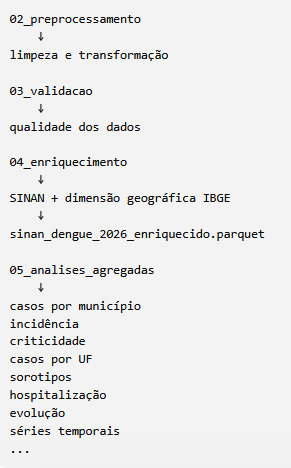